In [300]:
import scipy
import json
import numpy as np
import math

from scipy.optimize import curve_fit

from matplotlib import pyplot as plt

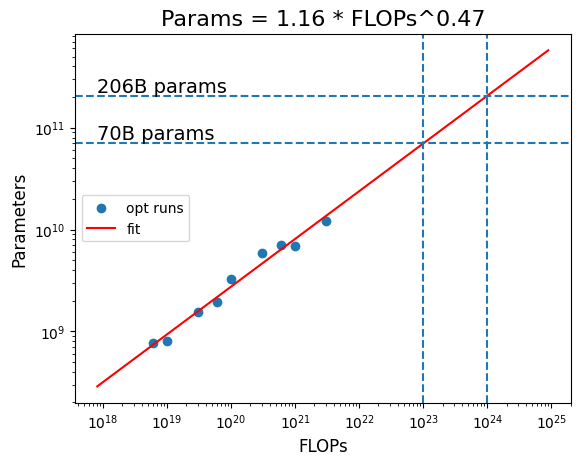

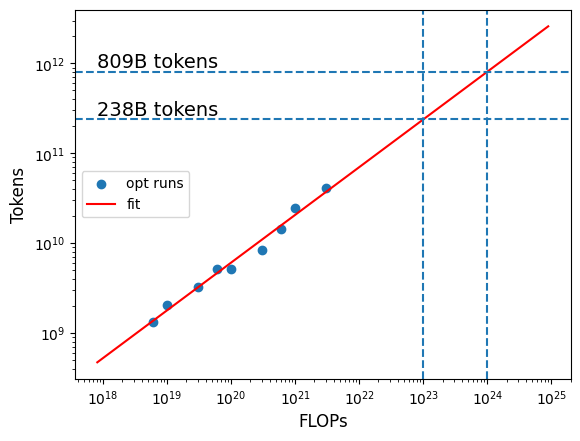

In [301]:
from math import log
from tkinter import font


runs_ = json.load(open("data/isoflops_curves.json", "r"))

def linear(x, power, log_const):
    return power * x + log_const

budget2runs = {}
for run in runs_:
    budget = run["compute_budget"]
    if budget not in budget2runs:
        budget2runs[budget] = []
    budget2runs[budget].append(run)

budget2best = {budget: min(runs, key=lambda run: run["final_loss"]) for budget, runs in budget2runs.items()}

budget = np.array(list(budget2best.keys()))
parameters = np.array([run["parameters"] for run in budget2best.values()])
losses = np.array([run["final_loss"] for run in budget2best.values()])

log_budget = np.log(budget)
log_params = np.log(parameters)
log_losses = np.log(losses)

popt, pcov = curve_fit(linear, log_budget, log_params)

power, log_const = popt
const = np.exp(log_const).astype(float)
scaling_low_wrt_params = f"Params = {const:.2f} * FLOPs^{power:.2f}"

log_budget_fit = np.linspace(min(log_budget)-2, max(log_budget) + 8, 100)
log_params_fit = linear(log_budget_fit, *popt)
params_fit, budget_fit = np.exp(log_params_fit), np.exp(log_budget_fit)

target_budget_ = np.array([1e23, 1e24])
target_log_budget_ = np.log(target_budget_)
target_log_params_ = linear(target_log_budget_, *popt)
target_params_ = np.exp(target_log_params_)

plt.scatter(budget, parameters, label="opt runs")
plt.plot(budget_fit, params_fit, color="red", label="fit")

# draw guide lines
for target_budget, target_params in zip(target_budget_.tolist(), target_params_.tolist()):
    plt.axvline(target_budget, linestyle="--")
    plt.axhline(target_params, linestyle="--")

    # annotate y-axis intersection
    plt.text(
        min(budget_fit),
        target_params,
        f"{target_params/1e9:.0f}B params",
        va="bottom",
        ha="left",
        fontsize=14
    )

plt.xscale("log", base=10)
plt.yscale("log", base=10)

plt.xlabel("FLOPs", fontsize=12)
plt.ylabel("Parameters", fontsize=12)
plt.title(scaling_low_wrt_params, fontsize=16)
plt.legend()
plt.show()


log_tokens = log_budget - log_params - math.log(6.0)
tokens = np.exp(log_tokens)
log_tokens_fit  = log_budget_fit - log_params_fit - math.log(6.0)
tokens_fit = np.exp(log_tokens_fit)
target_log_tokens_ = target_log_budget_ - target_log_params_ - math.log(6.0)
target_tokens_ = np.exp(target_log_tokens_)

plt.scatter(budget, tokens, label="opt runs")
plt.plot(budget_fit, tokens_fit, color="red", label="fit")

# draw guide lines
for target_budget, target_tokens in zip(target_budget_.tolist(), target_tokens_.tolist()):
    plt.axvline(target_budget, linestyle="--")
    plt.axhline(target_tokens, linestyle="--")

    # annotate y-axis intersection
    plt.text(
        min(budget_fit),
        target_tokens,
        f"{target_tokens/1e9:.0f}B tokens",
        va="bottom",
        ha="left",
        fontsize=14
    )

plt.xscale("log", base=10)
plt.yscale("log", base=10)

plt.xlabel("FLOPs", fontsize=12)
plt.ylabel("Tokens", fontsize=12)
plt.legend()
plt.show()



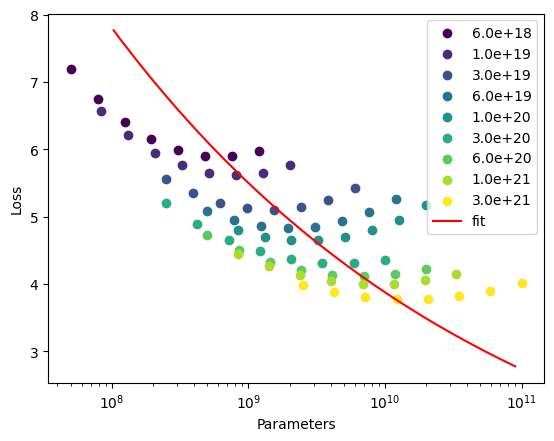

In [302]:
popt, pcov = curve_fit(linear, log_params, log_losses)

# full_parameters = [run["parameters"] for run in runs_]
# full_losses = [run["final_loss"] for run in runs_]

log_params_fit = np.linspace(min(log_params)-2, max(log_params)+2, 100)
log_losses_fit = linear(log_params_fit, *popt)
params_fit, losses_fit = np.exp(log_params_fit), np.exp(log_losses_fit)

sorted_budgets = sorted(budget2runs.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_budgets)))
for color, budget in zip(colors, sorted_budgets):
    runs = budget2runs[budget]
    parameters = [run["parameters"] for run in runs]
    losses = [run["final_loss"] for run in runs]
    plt.scatter(parameters, losses, color=color, label=f"{budget:.1e}")
plt.plot(params_fit, losses_fit, color="red", label="fit")

plt.xscale("log", base=10)

plt.xlabel("Parameters")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [303]:
from math import log
from tkinter import font

from sklearn.metrics import log_loss


scales = [
    "XS",
    "S",
    "M",
    "L",
    "XL",
]

runs_ = json.load(open("data/isoflops_curves.json", "r"))

def linear(log_x, power, log_const):
    return power * log_x + log_const

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

ASYMP_LOSS = 2.5
def chinchilla(N, A, alpha):
    # return E + A *N**(-alpha)
    return ASYMP_LOSS + A *N**(-alpha)  # we only have 5 data points; assume the asymptotic loss is 2.5, based on our observation that small-scale runs finish with losses between 3 and 4

import math

def compute_llama_style_config(target_params):
    d = (target_params / 0.1875) ** (1 / 3)

    hidden_size = round(d / 64) * 64

    config = {
        "hidden_size": hidden_size,
        "num_hidden_layers": hidden_size // 64,
        "num_attention_heads": hidden_size // 64,
        "head_dim": 64,
        "intermediate_size": round(hidden_size * 8 / 3 / 64) * 64,
    }

    n_nonembed = (
        12
        * config["num_hidden_layers"]
        * config["hidden_size"] ** 2
    )

    print(f"Target params: {target_params/1e6:.1f}M")
    print()
    for k, v in config.items():
        print(f"{k:25s} = {v}")

    print()
    print(f"Estimated non-embedding params = {n_nonembed/1e6:.1f}M")

    return config, n_nonembed


scale2results = {}
budget = []
parameters = []
losses = []
for scale in scales:
    scale2results[scale] = {}
    data = json.load(open(f"results/isoflops/scale_{scale}.json", "r"))
    runs = data["runs"]
    
    N_ = np.array([run["n_nonembed"] for run in runs])
    loss_ = np.array([run["final_val_loss"] for run in runs])
    
    popt, _ = curve_fit(parabola, np.log(N_), loss_)
    a, b, c = popt
    
    best_N = math.exp(-b/(2*a))
    best_loss = parabola(math.log(best_N), *popt)
    
    scale2results[scale]["FLOPs"] = data["target_C"]
    scale2results[scale]["N_"] = N_
    scale2results[scale]["loss_"] = loss_
    scale2results[scale]["best_N"] = best_N
    scale2results[scale]["best_loss"] = best_loss
    scale2results[scale]["parabola_fit"] = (a, b, c)
    
    budget.append(data["target_C"])
    parameters.append(best_N)
    losses.append(best_loss)

budget = np.array(budget)
parameters = np.array(parameters)
losses = np.array(losses)




/var/folders/x0/dw8k1jys3j948z1ld839h5br0000gn/T/ipykernel_44898/3499016170.py:72: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(parabola, np.log(N_), loss_)


In [304]:
N2mtp = {}
for scale in scales:
    data = json.load(open(f"results/isoflops/scale_{scale}.json", "r"))
    runs = data["runs"]
    for run in runs:
        arch_name = run["arch_name"]
        actual_c = run["actual_C"]
        actual_tera_flops = actual_c / 1e12
        time = run["used_runtime_seconds"]
        mtp = actual_tera_flops / time
        N2mtp[run["n_nonembed"]] = mtp


# print N2mtp in json, also use teraflops per second
print(json.dumps(N2mtp, indent=4))

mfu_tflops = 422
mfu = mfu_tflops*1e12
target_hours = 48

def estimate_flops(target_hours, mfu):
    seconds = target_hours*3600
    return mfu * seconds

target_budget = estimate_flops(target_hours, mfu)
print(f"Estimated FLOPs for {target_hours} hours at {mfu} TFLOPS: {target_budget:.2e}")

{
    "25165824": 119.01568861189246,
    "10616832": 84.05520210025846,
    "6144000": 54.139350566876516,
    "3145728": 38.38772941163967,
    "49152000": 172.88137431079713,
    "84934656": 220.31598763314338,
    "201326592": 314.98844649519276
}
Estimated FLOPs for 48 hours at 422000000000000.0 TFLOPS: 7.29e+19


target_budget: 7.29e+19, target_params: 5.85e+08
Target params: 585.0M

hidden_size               = 1472
num_hidden_layers         = 23
num_attention_heads       = 23
head_dim                  = 64
intermediate_size         = 3904

Estimated non-embedding params = 598.0M
Estimated D given actual N: 2.03e+10 tokens


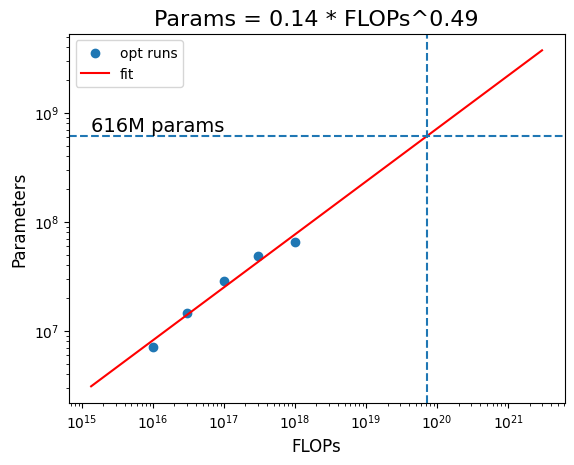

In [305]:


log_budget = np.log(budget)
log_params = np.log(parameters)
log_losses = np.log(losses)

popt, pcov = curve_fit(linear, log_budget, log_params)

power, log_const = popt
const = np.exp(log_const).astype(float)
scaling_low_wrt_params = f"Params = {const:.2f} * FLOPs^{power:.2f}"

log_budget_fit = np.linspace(min(log_budget)-2, max(log_budget) + 8, 100)
log_params_fit = linear(log_budget_fit, *popt)
params_fit, budget_fit = np.exp(log_params_fit), np.exp(log_budget_fit)

target_budget_ = np.array([target_budget])
target_log_budget_ = np.log(target_budget_)
target_log_params_ = linear(target_log_budget_, *popt)
target_params_ = np.exp(target_log_params_)

plt.scatter(budget, parameters, label="opt runs")
plt.plot(budget_fit, params_fit, color="red", label="fit")

# draw guide lines
for target_budget, target_params in zip(target_budget_.tolist(), target_params_.tolist()):
    plt.axvline(target_budget, linestyle="--")
    plt.axhline(target_params, linestyle="--")

    # annotate y-axis intersection
    plt.text(
        min(budget_fit),
        target_params,
        f"{target_params/1e6:.0f}M params",
        va="bottom",
        ha="left",
        fontsize=14
    )
    
    target_params = target_params*5.7/6
    print(f"target_budget: {target_budget:.2e}, target_params: {target_params:.2e}")
    config, actual_N = compute_llama_style_config(target_params)
    
    actual_D = target_budget / (6 * actual_N)
    print(f"Estimated D given actual N: {actual_D:.2e} tokens")

plt.xscale("log", base=10)
plt.yscale("log", base=10)

plt.xlabel("FLOPs", fontsize=12)
plt.ylabel("Parameters", fontsize=12)
plt.title(scaling_low_wrt_params, fontsize=16)
plt.legend()
plt.show()

/var/folders/x0/dw8k1jys3j948z1ld839h5br0000gn/T/ipykernel_44898/3499016170.py:26: RuntimeWarning: overflow encountered in power
  return ASYMP_LOSS + A *N**(-alpha)  # we only have 5 data points; assume the asymptotic loss is 2.5, based on our observation that small-scale runs finish with losses between 3 and 4


598032384 3.0356665499620252


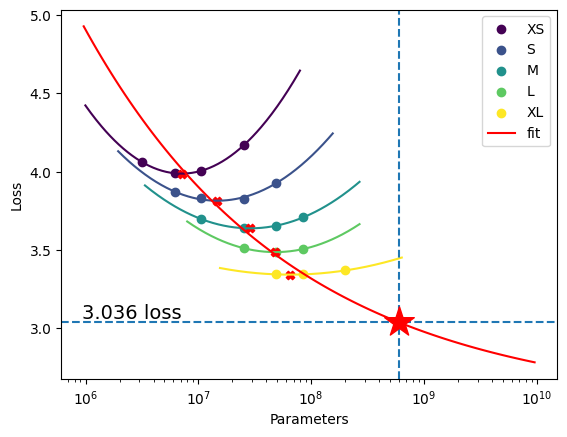

In [306]:
# popt, pcov = curve_fit(linear, log_params, losses)

# log_params_fit = np.linspace(min(log_params)-2, max(log_params)+2, 100)
# params_fit = np.exp(log_params_fit)
# losses_fit = linear(log_params_fit, *popt)

# popt, pcov = curve_fit(linear, log_params, log_losses)

# log_params_fit = np.linspace(min(log_params)-2, max(log_params)+5, 100)
# params_fit = np.exp(log_params_fit)
# log_losses_fit = linear(log_params_fit, *popt)
# losses_fit = np.exp(log_losses_fit)

popt, pcov = curve_fit(chinchilla, parameters, losses)

log_params_fit = np.linspace(min(log_params)-2, max(log_params)+5, 100)
params_fit = np.exp(log_params_fit)
losses_fit = chinchilla(params_fit, *popt)

colors = plt.cm.viridis(np.linspace(0, 1, len(scales)))
for i, scale in enumerate(scales):
    data = scale2results[scale]
    N_ = data["N_"]
    loss_ = data["loss_"]
    plt.scatter(N_, loss_, color=colors[i], label=scale)
    a,b,c = data["parabola_fit"]
    # smooth curve
    N_fit = np.logspace(np.log10(N_.min())-0.5, np.log10(N_.max())+0.5, 200)
    log_N_fit = np.log(N_fit)
    loss_fit = a * log_N_fit**2 + b * log_N_fit + c
    # plot parabola
    plt.plot(N_fit, loss_fit, color=colors[i])
    # plot the best point
    plt.scatter(data["best_N"], data["best_loss"], color="red", marker="X")
    
plt.plot(params_fit, losses_fit, color="red", label="fit")

# annotate the target point
target_loss = chinchilla(actual_N, *popt)
print(actual_N, target_loss)
plt.axvline(actual_N, linestyle="--")
plt.axhline(target_loss, linestyle="--")
plt.scatter(actual_N, target_loss, color="red", marker="*", s=500, zorder=10)
# annotate y-axis intersection
plt.text(
    min(parameters),
    target_loss,
    f"{target_loss:.3f} loss",
    va="bottom",
    ha="right",
    fontsize=14
)

plt.xscale("log", base=10)

plt.xlabel("Parameters")
plt.ylabel("Loss")
plt.legend()
plt.show()